In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_rohde_schwarz_csv(path):
    raw_data = pd.read_csv(path, header=None)
    data_lines = raw_data.iloc[2:, 0]
    split = data_lines.str.split(";", expand=True)

    header = split.iloc[0]
    data = split.iloc[1:].reset_index(drop=True)
    data.columns = header

    data = data.replace("", np.nan)
    data = data.dropna(subset=[header[0]])

    for col in data.columns:
        data[col] = data[col].astype(float)

    data = data.rename(columns={data.columns[0]: "freq_Hz",data.columns[1]: "re_S21",data.columns[2]: "im_S21", })

    data["mag_lin"] = np.sqrt(data["re_S21"]**2 + data["im_S21"]**2)
    data["mag_dB"] = 20 * np.log10(data["mag_lin"].clip(lower=1e-15))

    # Correct for the -10 dB attenuator inserted after calibration
    data["mag_dB_corr"] = data["mag_dB"] + 10

    return data

/tmp/ipykernel_648/3300644239.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace("", np.nan)
/tmp/ipykernel_648/3300644239.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace("", np.nan)
/tmp/ipykernel_648/3300644239.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', 

Selected range: 1.3900–1.4600 GHz

Left polarization LNA:
  Max = 12.975 dB at 1.390245 GHz
  Min = 11.934 dB at 1.459780 GHz

Right polarization LNA:
  Max = 13.436 dB at 1.425763 GHz
  Min = 13.030 dB at 1.390245 GHz



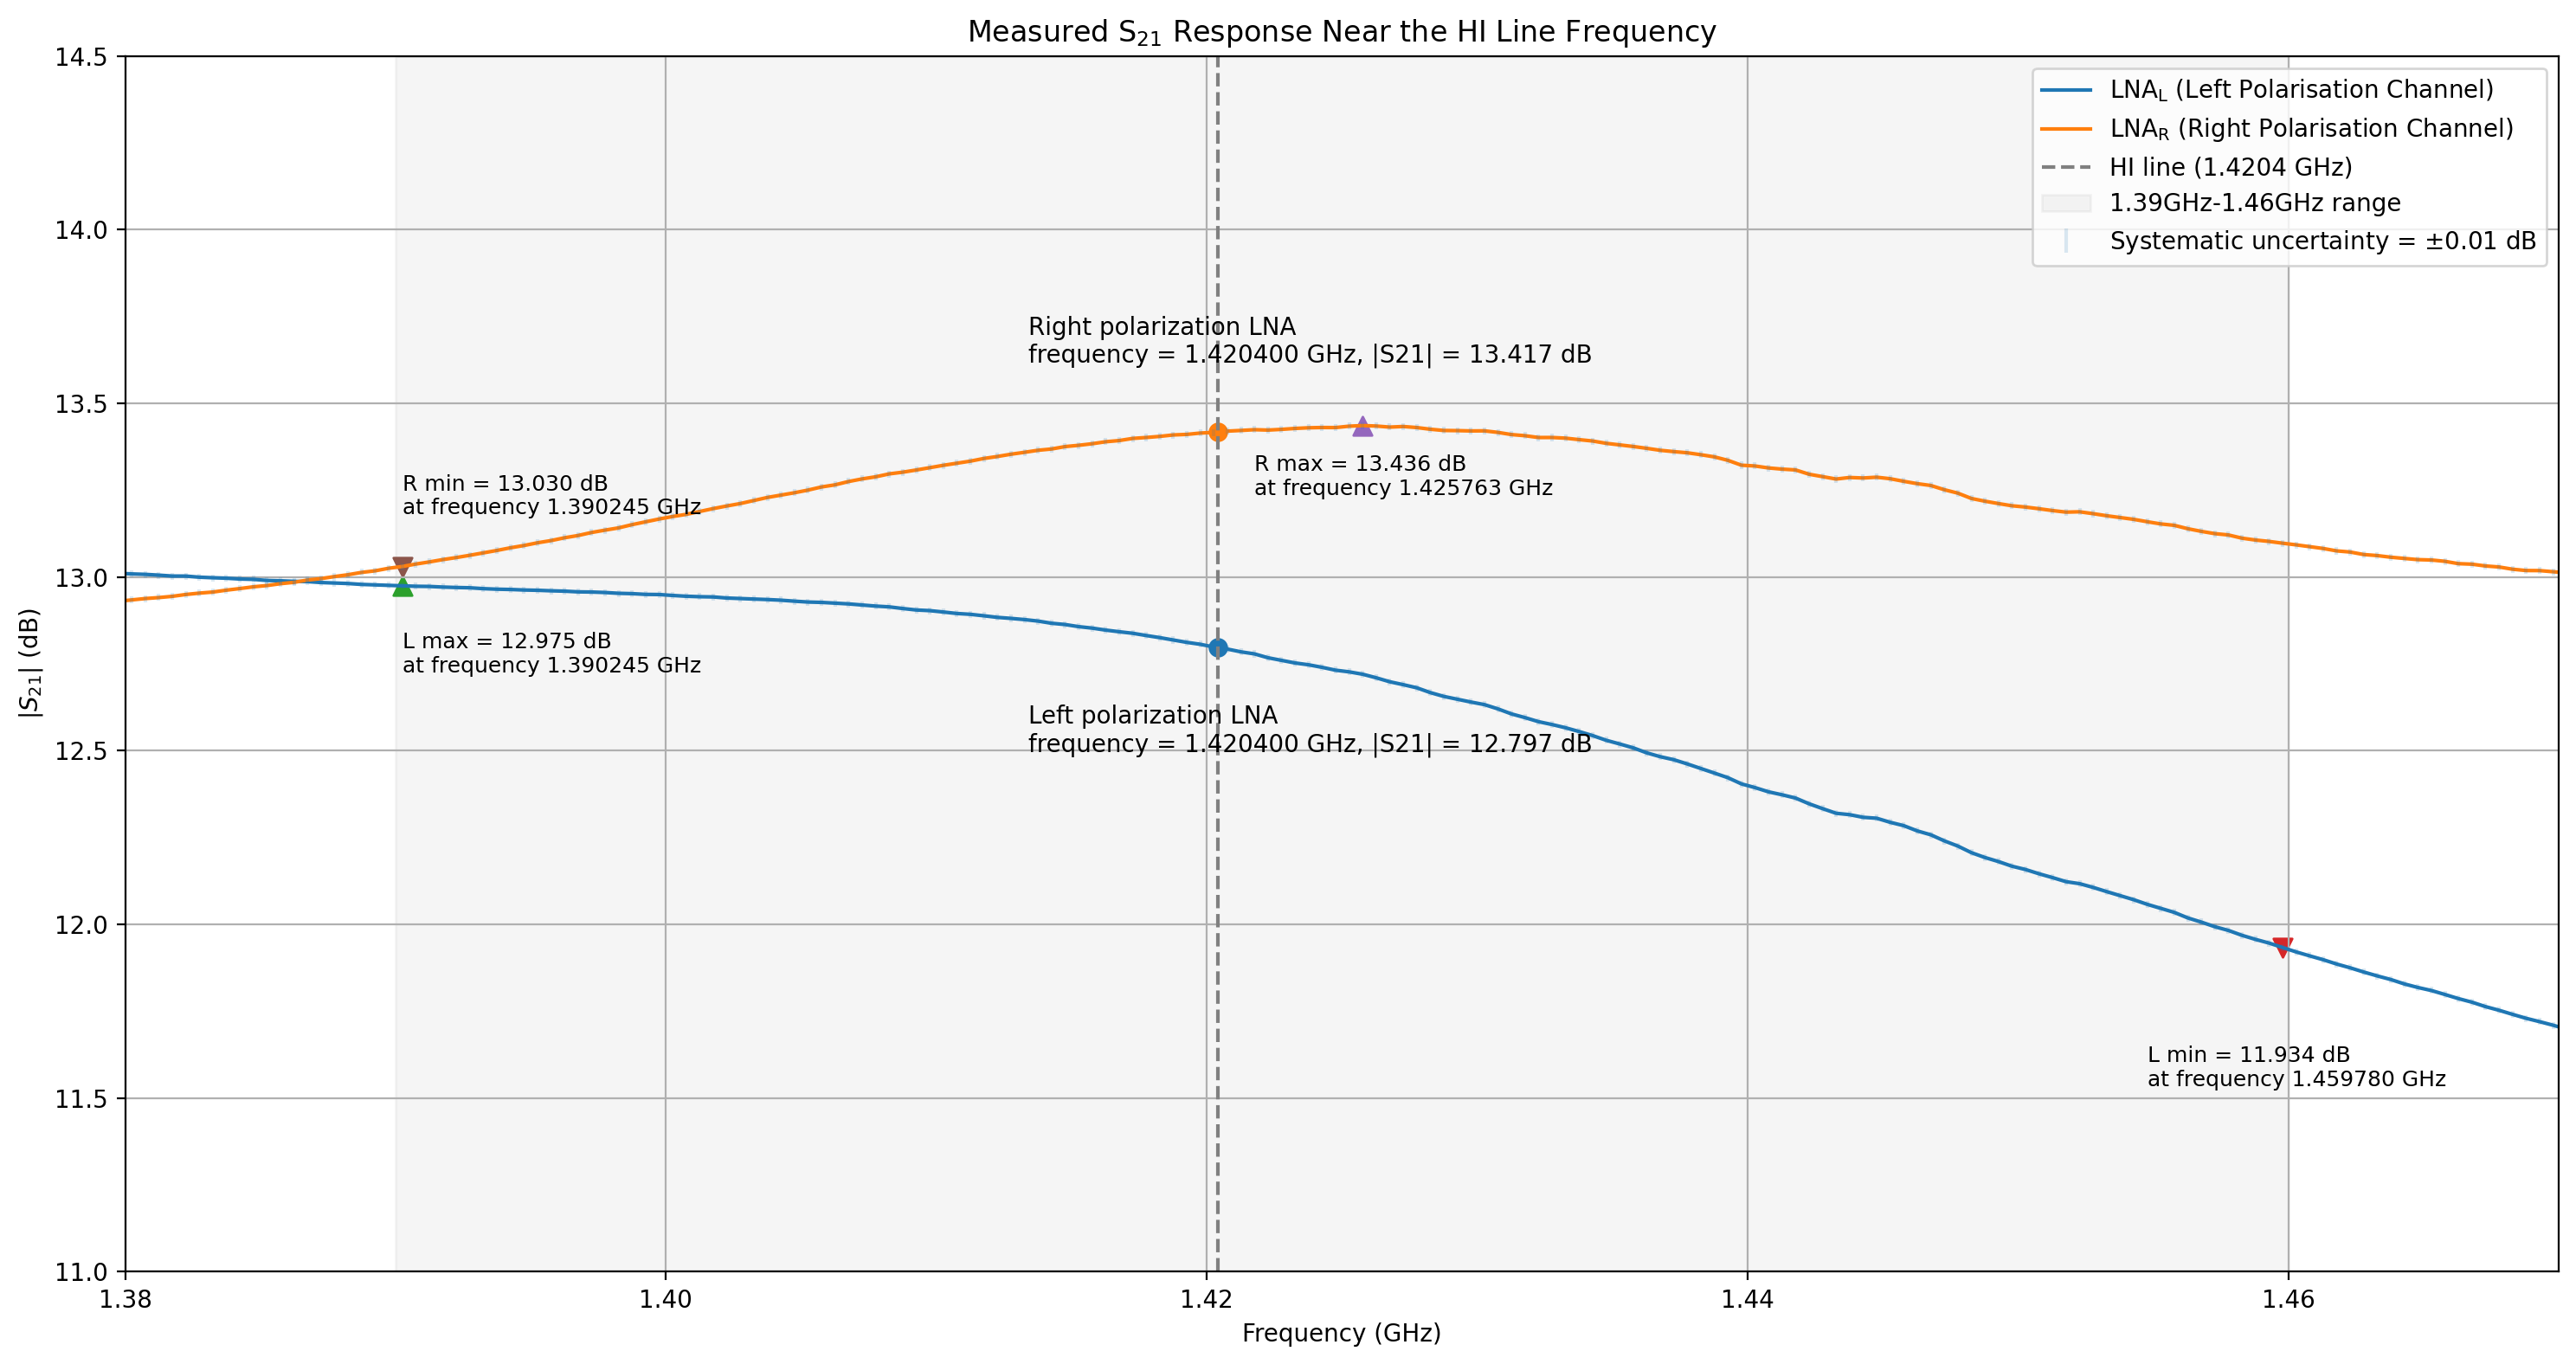

In [27]:
def get_range_min_max(df, fmin_Hz, fmax_Hz, ycol="mag_dB_corr"):
    """
    Return min/max values and their frequencies within the selected frequency range.
    """
    mask = (df["freq_Hz"] >= fmin_Hz) & (df["freq_Hz"] <= fmax_Hz)
    sub = df.loc[mask].copy()

    if sub.empty:
        raise ValueError("No data points found in the selected frequency range.")

    idx_max = sub[ycol].idxmax()
    idx_min = sub[ycol].idxmin()

    result = {"max_freq_Hz": df.loc[idx_max, "freq_Hz"],"max_val_dB": df.loc[idx_max, ycol],"min_freq_Hz": df.loc[idx_min, "freq_Hz"],"min_val_dB":df.loc[idx_min, ycol],}
    return result


black_1g = load_rohde_schwarz_csv("2025-12-04_black-gain_1GHz.csv")
red_1g   = load_rohde_schwarz_csv("2025-12-04_red-gain_1GHz.csv")
black_all = load_rohde_schwarz_csv("2025-12-04_Black-gain.csv")
red_all   = load_rohde_schwarz_csv("2025-12-04_red-gain.csv")

target_freq = 1.4204e9


range_min_GHz = 1.39
range_max_GHz = 1.46
range_min_Hz = range_min_GHz * 1e9
range_max_Hz = range_max_GHz * 1e9


black_gain_interp = np.interp(target_freq, black_1g["freq_Hz"], black_1g["mag_dB_corr"])
red_gain_interp   = np.interp(target_freq, red_1g["freq_Hz"], red_1g["mag_dB_corr"])


black_stats = get_range_min_max(black_1g, range_min_Hz, range_max_Hz)
red_stats   = get_range_min_max(red_1g, range_min_Hz, range_max_Hz)

print(f"Selected range: {range_min_GHz:.4f}–{range_max_GHz:.4f} GHz\n")

print("Left polarization LNA:")
print(f"  Max = {black_stats['max_val_dB']:.3f} dB at {black_stats['max_freq_Hz']/1e9:.6f} GHz")
print(f"  Min = {black_stats['min_val_dB']:.3f} dB at {black_stats['min_freq_Hz']/1e9:.6f} GHz\n")

print("Right polarization LNA:")
print(f"  Max = {red_stats['max_val_dB']:.3f} dB at {red_stats['max_freq_Hz']/1e9:.6f} GHz")
print(f"  Min = {red_stats['min_val_dB']:.3f} dB at {red_stats['min_freq_Hz']/1e9:.6f} GHz\n")

plt.figure(figsize=(15, 8))

plt.plot(black_1g["freq_Hz"] / 1e9,black_1g["mag_dB_corr"],label="LNA$_\\mathrm{L}$ (Left Polarisation Channel)")

plt.plot(red_1g["freq_Hz"] / 1e9,red_1g["mag_dB_corr"],label="LNA$_\\mathrm{R}$ (Right Polarisation Channel)")

# systematic uncertainty
plt.errorbar(black_1g["freq_Hz"] / 1e9,black_1g["mag_dB_corr"],yerr=0.01,fmt='none',alpha=0.16)

plt.errorbar(red_1g["freq_Hz"] / 1e9,red_1g["mag_dB_corr"],yerr=0.01,fmt='none',alpha=0.16,label=r"Systematic uncertainty = $\pm 0.01$ dB")


plt.axvline(target_freq / 1e9,linestyle="--",color="gray",label="HI line (1.4204 GHz)")


plt.axvspan(range_min_GHz, range_max_GHz, alpha=0.08, color="gray", label="1.39 GHz-1.46GHz range")


plt.scatter(target_freq / 1e9, black_gain_interp, s=50)
plt.annotate(f"Left polarization LNA\n" f"frequency = {target_freq/1e9:.6f} GHz, |S21| = {black_gain_interp:.3f} dB",xy=(target_freq / 1e9, black_gain_interp), xytext=(target_freq / 1e9 - 0.007, black_gain_interp - 0.3), fontsize=10)

plt.scatter(target_freq / 1e9, red_gain_interp, s=50)
plt.annotate(f"Right polarization LNA\n"f"frequency = {target_freq/1e9:.6f} GHz, |S21| = {red_gain_interp:.3f} dB",xy=(target_freq / 1e9, red_gain_interp),xytext=(target_freq / 1e9 - 0.007, red_gain_interp + 0.2),fontsize=10)

# Mark max/min points in selected range
plt.scatter(black_stats["max_freq_Hz"] / 1e9, black_stats["max_val_dB"], s=60, marker="^")
plt.scatter(black_stats["min_freq_Hz"] / 1e9, black_stats["min_val_dB"], s=60, marker="v")

plt.scatter(red_stats["max_freq_Hz"] / 1e9, red_stats["max_val_dB"], s=60, marker="^")
plt.scatter(red_stats["min_freq_Hz"] / 1e9, red_stats["min_val_dB"], s=60, marker="v")

plt.annotate(f"L max = {black_stats['max_val_dB']:.3f} dB\nat frequency {black_stats['max_freq_Hz']/1e9:.6f} GHz",xy=(black_stats["max_freq_Hz"] / 1e9, black_stats["max_val_dB"]),xytext=(black_stats["max_freq_Hz"] / 1e9 + 0.00, black_stats["max_val_dB"] - 0.25),fontsize=9)

plt.annotate(f"L min = {black_stats['min_val_dB']:.3f} dB\nat frequency {black_stats['min_freq_Hz']/1e9:.6f} GHz",xy=(black_stats["min_freq_Hz"] / 1e9 , black_stats["min_val_dB"]), xytext=(black_stats["min_freq_Hz"] / 1e9 - 0.005, black_stats["min_val_dB"] - 0.4),fontsize=9)

plt.annotate( f"R max = {red_stats['max_val_dB']:.3f} dB\nat frequency {red_stats['max_freq_Hz']/1e9:.6f} GHz",xy=(red_stats["max_freq_Hz"] / 1e9, red_stats["max_val_dB"]),xytext=(red_stats["max_freq_Hz"] / 1e9 - 0.004, red_stats["max_val_dB"] - 0.2),fontsize=9)

plt.annotate(f"R min = {red_stats['min_val_dB']:.3f} dB\nat frequency {red_stats['min_freq_Hz']/1e9:.6f} GHz",xy=(red_stats["min_freq_Hz"] / 1e9, red_stats["min_val_dB"]),xytext=(red_stats["min_freq_Hz"] / 1e9 + 0.00, red_stats["min_val_dB"] + 0.15),fontsize=9)

plt.xlabel("Frequency (GHz)")
plt.ylabel(r"$|S_{21}|$ (dB)")
plt.xlim(1.38, 1.47)
plt.ylim(11, 14.5)
plt.title("Measured S$_{21}$ Response Near the HI Line Frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
red_interp_full = np.interp( black_1g["freq_Hz"], red_1g["freq_Hz"], red_1g["mag_dB_corr"])
delta_curve = red_interp_full - black_1g["mag_dB_corr"].values

delta_at_HI = np.interp(1.4204e9, black_1g["freq_Hz"], delta_curve)


mask_below = black_1g["freq_Hz"].values < 1.42e9
delta_below_mean = np.mean(delta_curve[mask_below])
delta_below_std  = np.std(delta_curve[mask_below])


mask_above = black_1g["freq_Hz"].values > 1.42e9
delta_above_max = np.max(delta_curve[mask_above])

In [6]:
#Peak gain and peak frequency
black_peak_dB   = black_1g["mag_dB_corr"].max()
black_peak_freq = black_1g.loc[black_1g["mag_dB_corr"].idxmax(), "freq_Hz"] / 1e9

red_peak_dB   = red_1g["mag_dB_corr"].max()
red_peak_freq = red_1g.loc[red_1g["mag_dB_corr"].idxmax(), "freq_Hz"] / 1e9

# Gain at HI frequency 
# black_gain_interp, red_gain_interp

# Gain difference at HI frequency 
delta_at_HI = red_gain_interp - black_gain_interp

# Difference curve across full band 
# Interpolate red onto black's frequency axis first
red_interp_full = np.interp(
    black_1g["freq_Hz"], red_1g["freq_Hz"], red_1g["mag_dB_corr"]
)
delta_curve = red_interp_full - black_1g["mag_dB_corr"].values

delta_mean  = np.mean(delta_curve)
delta_std   = np.std(delta_curve)
delta_max   = np.max(np.abs(delta_curve))

# Gain flatness within HI band (1410-1430 MHz) 
for df, name in [(black_1g, "Left"), (red_1g, "Right")]:
    mask = (df["freq_Hz"] >= 1.41e9) & (df["freq_Hz"] <= 1.43e9)
    band = df.loc[mask, "mag_dB_corr"]
    print(f"{name}: HI-band gain = {band.mean():.3f} ± {band.std():.3f} dB, "
          f"peak-to-peak ripple = {band.max()-band.min():.3f} dB")

Left: HI-band gain = 12.791 ± 0.078 dB, peak-to-peak ripple = 0.259 dB
Right: HI-band gain = 13.400 ± 0.034 dB, peak-to-peak ripple = 0.114 dB


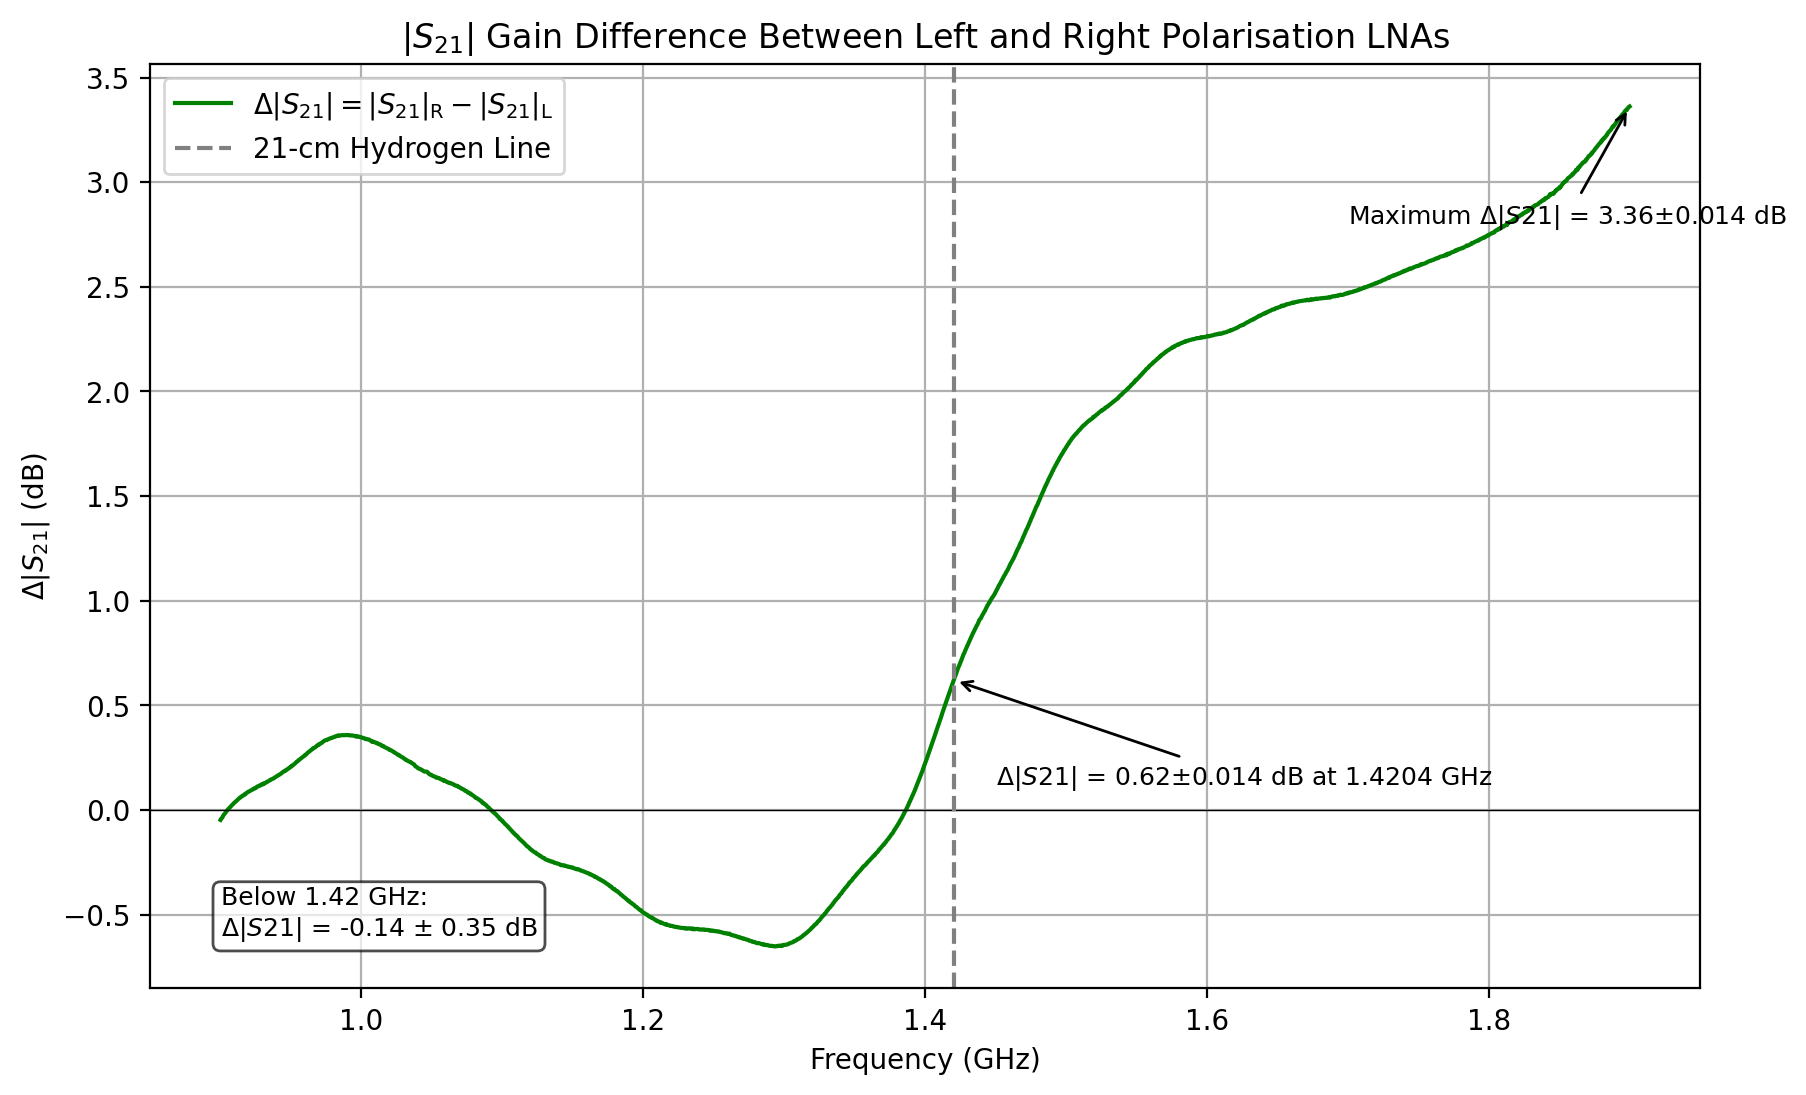

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(black_1g["freq_Hz"]/1e9, delta_curve, color='green',label=r"$\Delta|S_{21}| = |S_{21}|_\mathrm{R} - |S_{21}|_\mathrm{L}$")
ax.set_title(r"$|S_{21}|$ Gain Difference Between Left and Right Polarisation LNAs")
ax.axhline(0, color='k', lw=0.5)
ax.axvline(1.4204, color='gray', linestyle='--', label='21-cm Hydrogen Line')

ax.annotate(f"$\Delta |S21|$ = {delta_at_HI:.2f}$\pm0.014$ dB at 1.4204 GHz",xy=(1.4204, delta_at_HI),xytext=(1.45, delta_at_HI - 0.5),arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.annotate(f"Below 1.42 GHz:\n$\Delta|S21|$ = {delta_below_mean:.2f} ± {delta_below_std:.2f} dB",xy=(1.1, delta_below_mean),xytext=(0.9, -0.6), fontsize=9,bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.annotate(f"Maximum $\Delta|S21|$ = {delta_above_max:.2f}$\pm0.014$ dB",xy=(black_1g["freq_Hz"].values[np.argmax(delta_curve[mask_above]) + mask_above.argmax()] / 1e9,delta_above_max),xytext=(1.7, 2.8), fontsize=9,arrowprops=dict(arrowstyle="->"))


ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$\Delta|S_{21}|$ (dB)")
ax.legend(); ax.grid(True)

In [8]:

delta_at_HI = np.interp(1.4204e9, black_1g["freq_Hz"], delta_curve)


mask_below = black_1g["freq_Hz"] < 1.42e9
delta_below_mean = np.mean(delta_curve[mask_below])
delta_below_std  = np.std(delta_curve[mask_below])


mask_above = black_1g["freq_Hz"] > 1.42e9
delta_above_max = np.max(delta_curve[mask_above])


sign_changes = np.where(np.diff(np.sign(delta_curve)))[0]

zero_cross_freq = black_1g["freq_Hz"].values[sign_changes[-1]] / 1e9

print(f"ΔG at HI line:{delta_at_HI:.3f} dB")
print(f"ΔG below 1.42 GHz:{delta_below_mean:.3f} ± {delta_below_std:.3f} dB")
print(f"ΔG max above 1.42 GHz:{delta_above_max:.3f} dB")
print(f"Zero crossing:{zero_cross_freq:.3f} GHz")

ΔG at HI line:0.621 dB
ΔG below 1.42 GHz:-0.137 ± 0.347 dB
ΔG max above 1.42 GHz:3.362 dB
Zero crossing:1.386 GHz


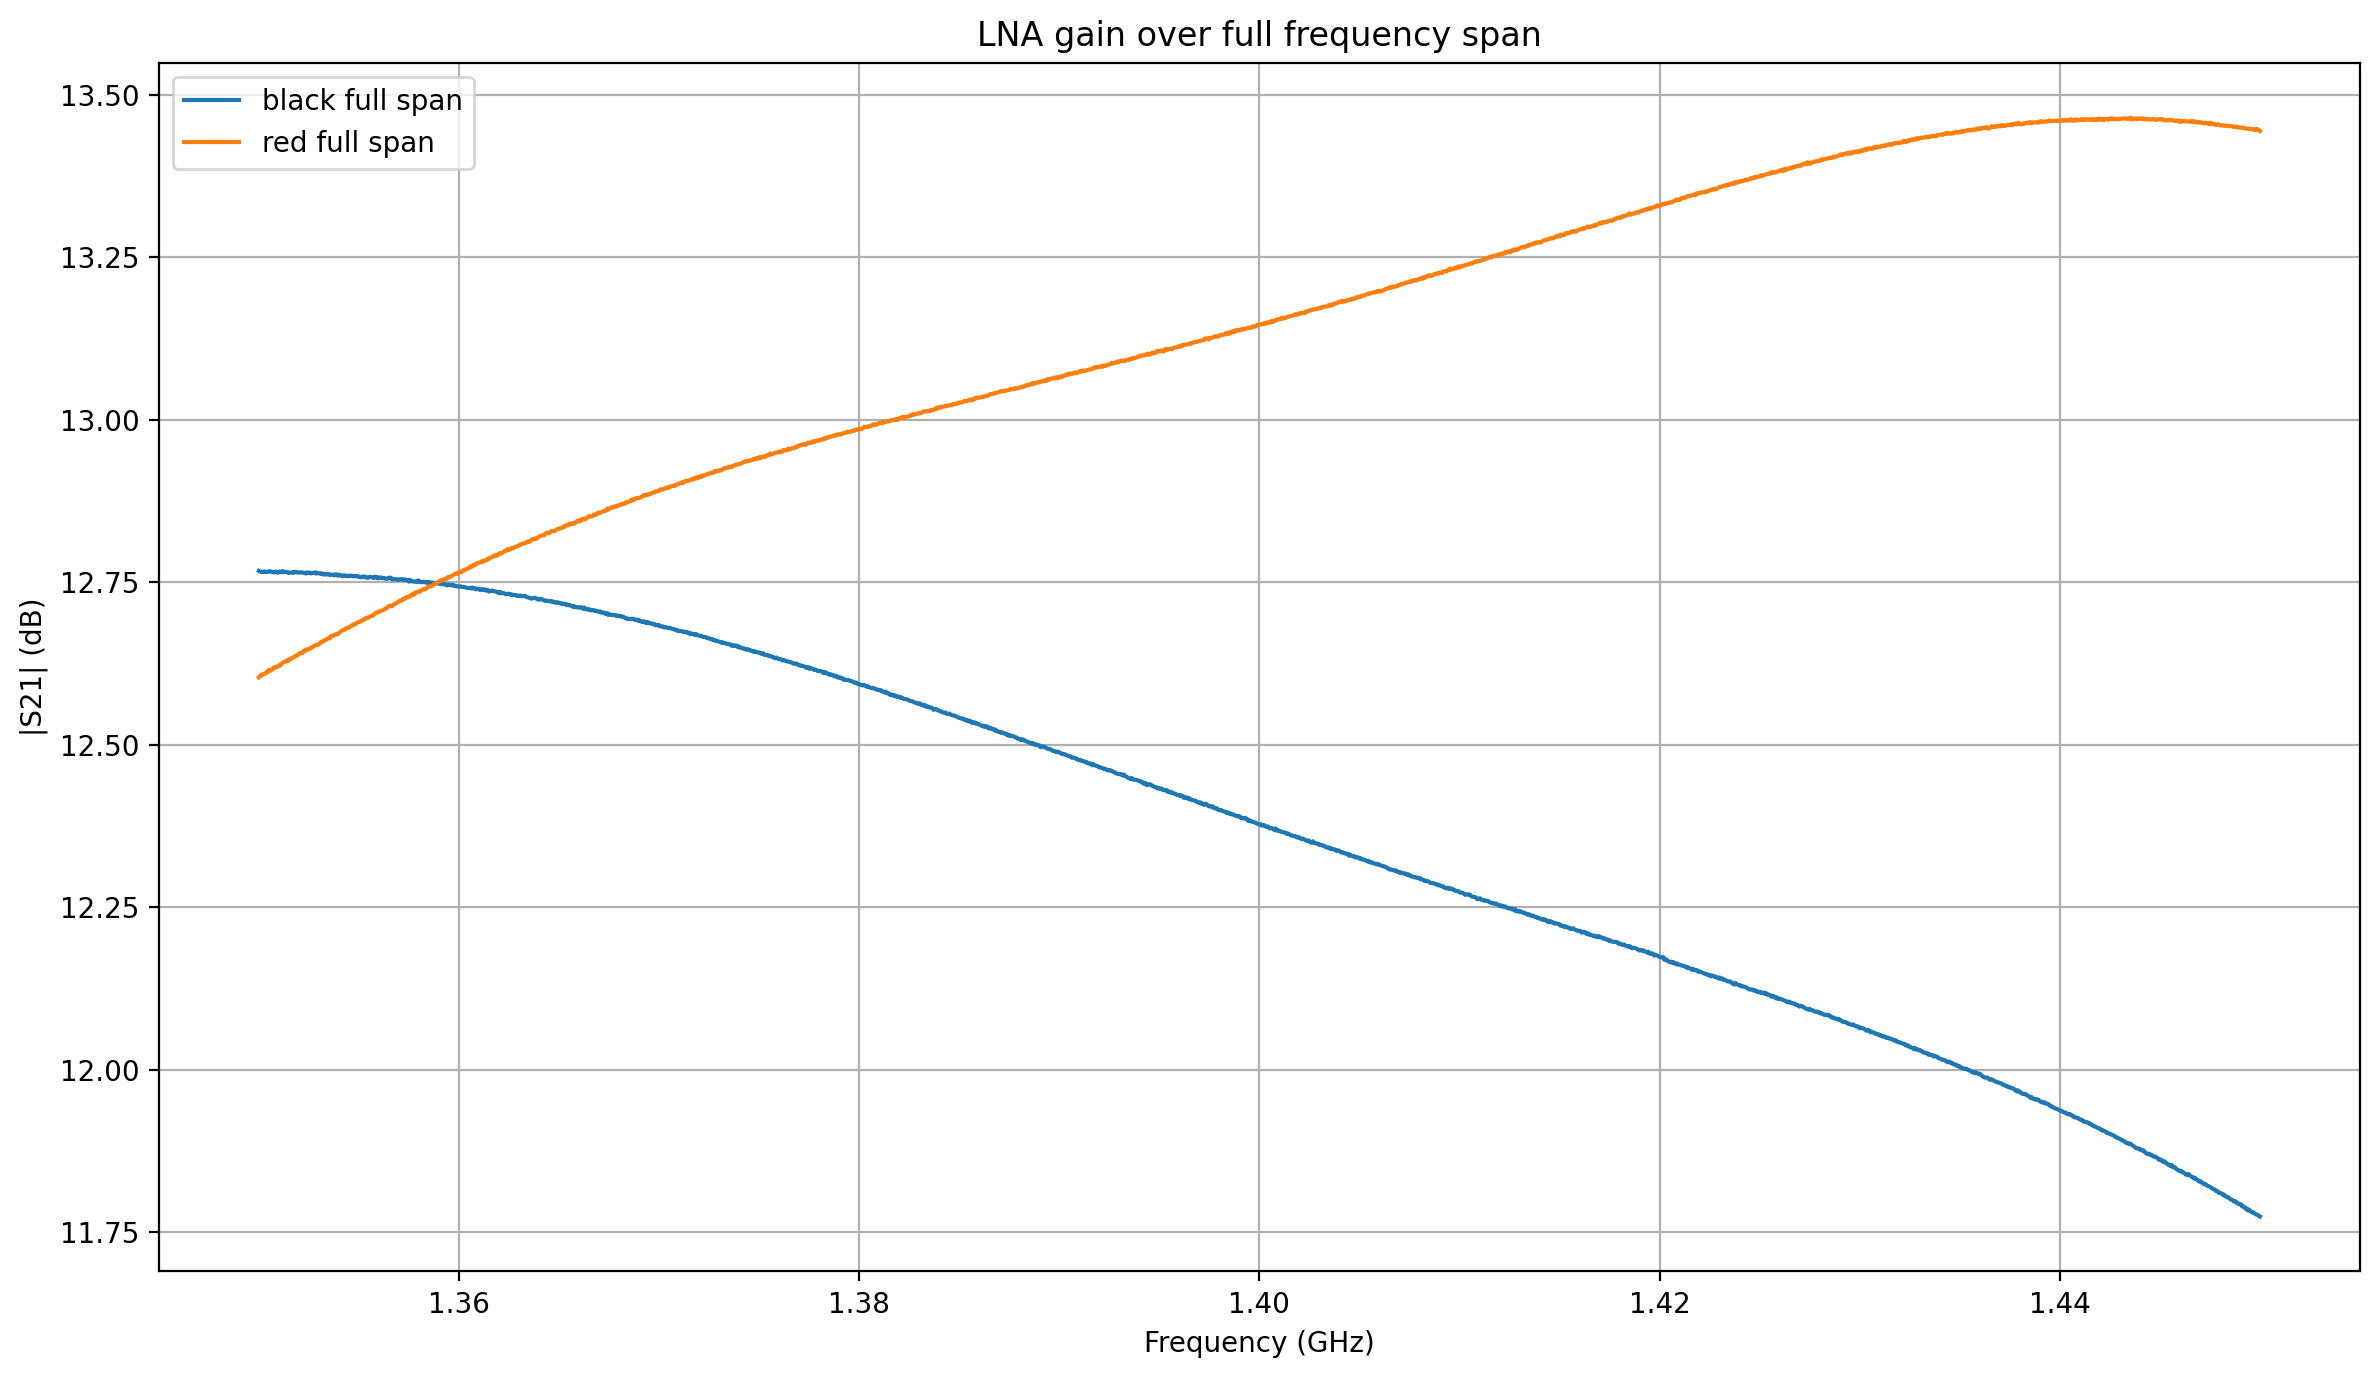

In [12]:
#full span
plt.figure()
plt.plot(black_all["freq_Hz"]/1e9, black_all["mag_dB"]+10, label="black full span")
plt.plot(red_all["freq_Hz"]/1e9,   red_all["mag_dB"]+10,   label="red full span")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21| (dB)")
plt.title("LNA gain over full frequency span")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_648/3784222796.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace("", np.nan)
/tmp/ipykernel_648/3784222796.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace("", np.nan)
/tmp/ipykernel_648/3784222796.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', 

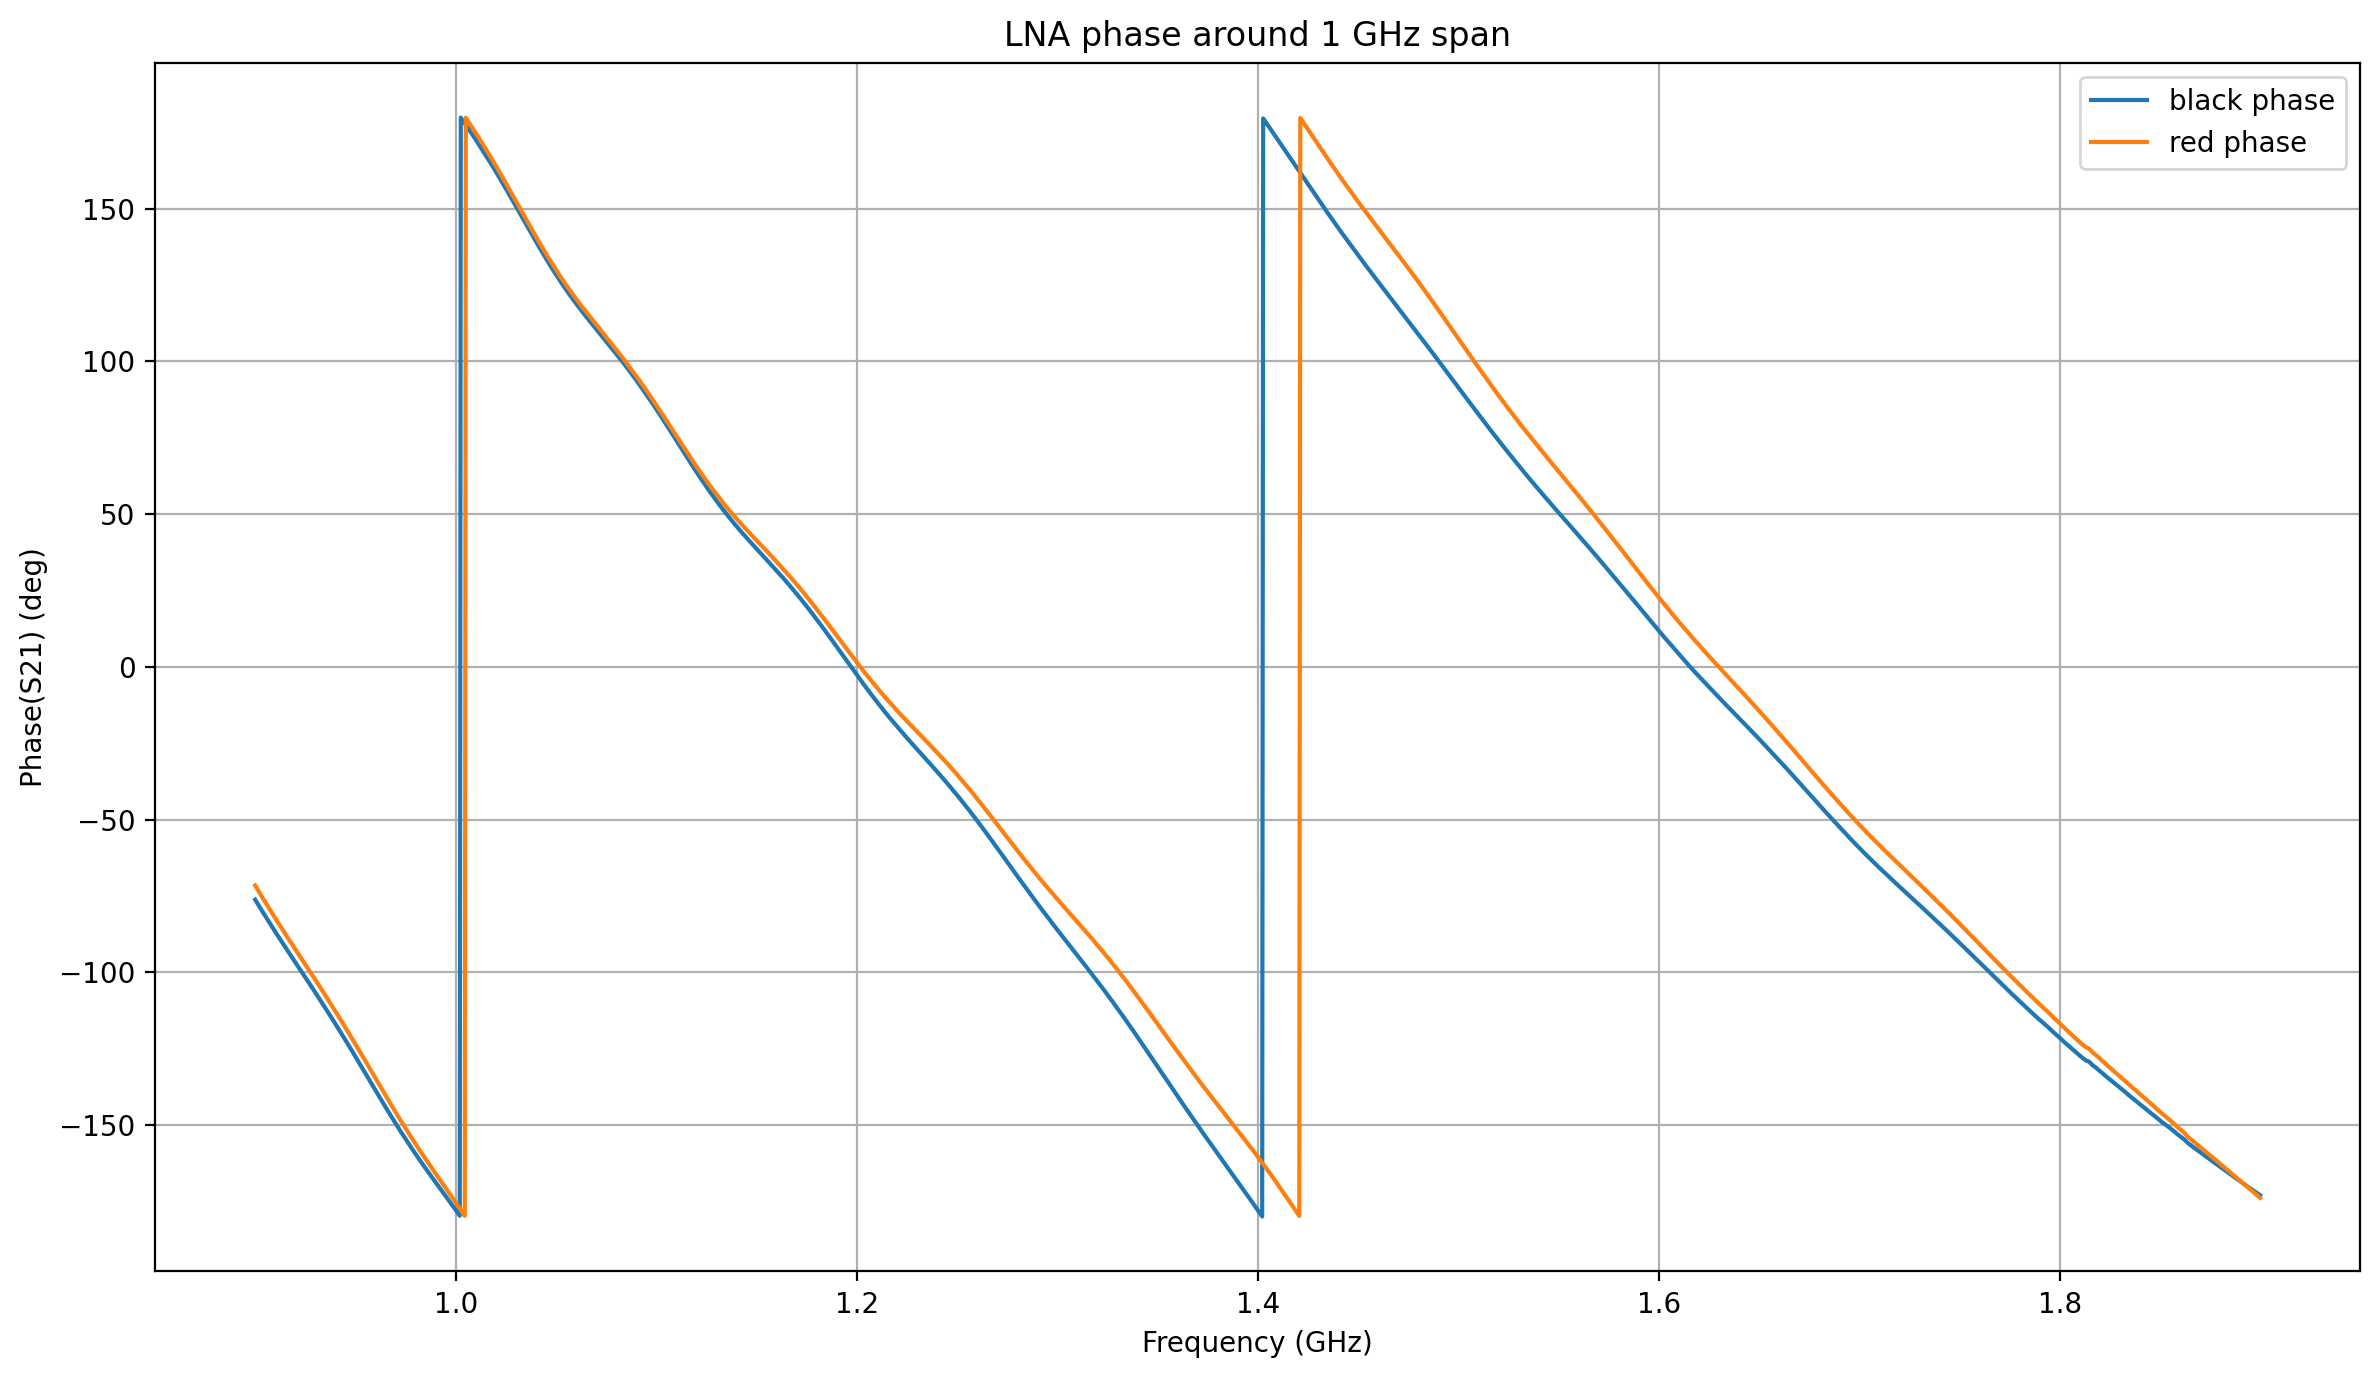

In [10]:
def load_rohde_schwarz_csv(path: str) -> pd.DataFrame:
    """
    read Rohde & Schwarz VNA and calculate：

    """

    raw = pd.read_csv(path, header=None)
    data_lines = raw.iloc[2:, 0]
    split = data_lines.str.split(";", expand=True)


    header = split.iloc[0]
    data = split.iloc[1:].reset_index(drop=True)
    data.columns = header


    data = data.replace("", np.nan)
    data = data.dropna(subset=[header[0]])


    for col in data.columns:
        data[col] = data[col].astype(float)


    data = data.rename(columns={
        data.columns[0]: "freq_Hz",
        data.columns[1]: "re_S21",
        data.columns[2]: "im_S21",
    })


    data["mag_lin"] = np.sqrt(data["re_S21"]**2 + data["im_S21"]**2)
    # dB
    data["mag_dB"] = 20 * np.log10(data["mag_lin"].clip(lower=1e-15))

    # phase rad and deg
    data["phase_rad"] = np.arctan2(data["im_S21"], data["re_S21"])
    data["phase_deg"] = np.degrees(data["phase_rad"])

    return data




def compute_group_delay(df: pd.DataFrame):

    phi = np.unwrap(df["phase_rad"].values)        
    f = df["freq_Hz"].values
    omega = 2 * np.pi * f

    dphi = np.diff(phi)
    domega = np.diff(omega)
    tau = -dphi / domega          # second

    # medium etween two close points
    f_mid = 0.5 * (f[1:] + f[:-1])
    return f_mid, tau


# 3. ±3 dB passband and gain
def band_3dB(df: pd.DataFrame, label="trace"):

    mag = df["mag_dB"].values
    f = df["freq_Hz"].values

    max_gain = mag.max()
    max_idx = mag.argmax()
    f_peak = f[max_idx]

    thr = max_gain - 3.0     # -3 dB 

    mask = mag >= thr
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return {"label": label,"peak_gain_dB": max_gain,"peak_freq_Hz": f_peak,"f_low_Hz": None,"f_high_Hz": None, }

    f_low = f[idx[0]]
    f_high = f[idx[-1]]

    return {"label": label,"peak_gain_dB": max_gain,"peak_freq_Hz": f_peak,"f_low_Hz": f_low,"f_high_Hz": f_high,}



def moving_average(x, N=11):
    """

    """
    kernel = np.ones(N) / N
    return np.convolve(x, kernel, mode="same")



if __name__ == "__main__":
    black_1g  = load_rohde_schwarz_csv("2025-12-04_black-gain_1GHz.csv")
    red_1g    = load_rohde_schwarz_csv("2025-12-04_red-gain_1GHz.csv")
    black_all = load_rohde_schwarz_csv("2025-12-04_Black-gain.csv")
    red_all   = load_rohde_schwarz_csv("2025-12-04_red-gain.csv") # 4 traces



    # Phase(S21)
    plt.figure()
    plt.plot(black_1g["freq_Hz"]/1e9, black_1g["phase_deg"], label="black phase")
    plt.plot(red_1g["freq_Hz"]/1e9,   red_1g["phase_deg"],   label="red phase")
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Phase(S21) (deg)")
    plt.title("LNA phase around 1 GHz span")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



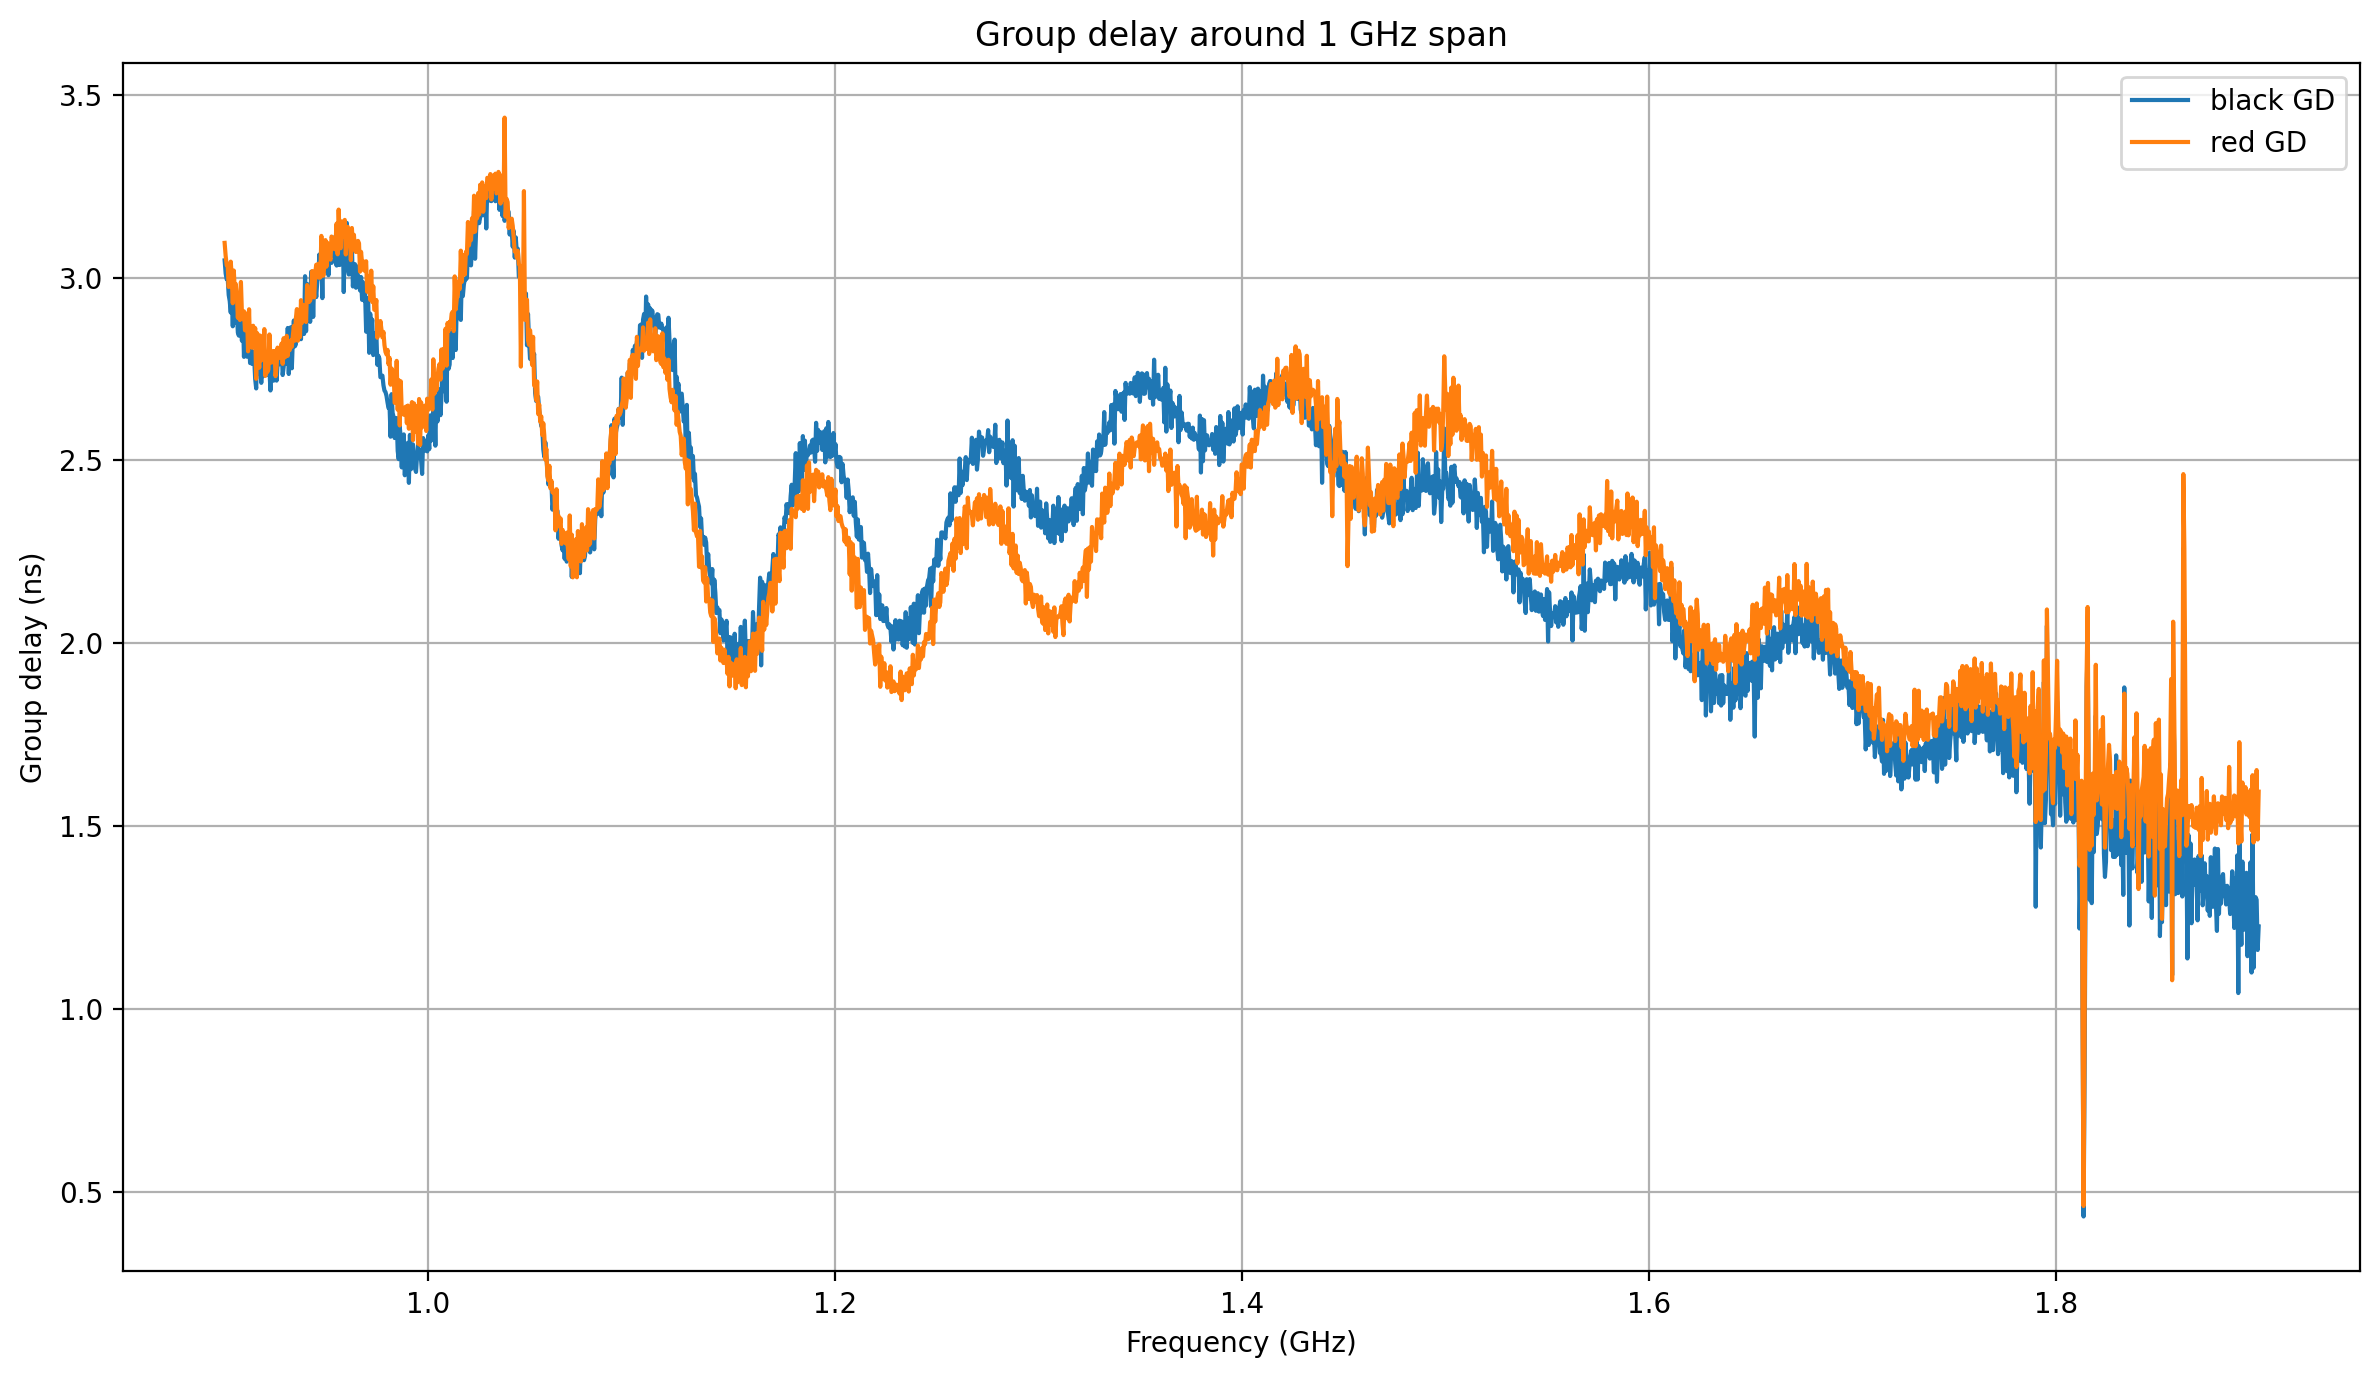

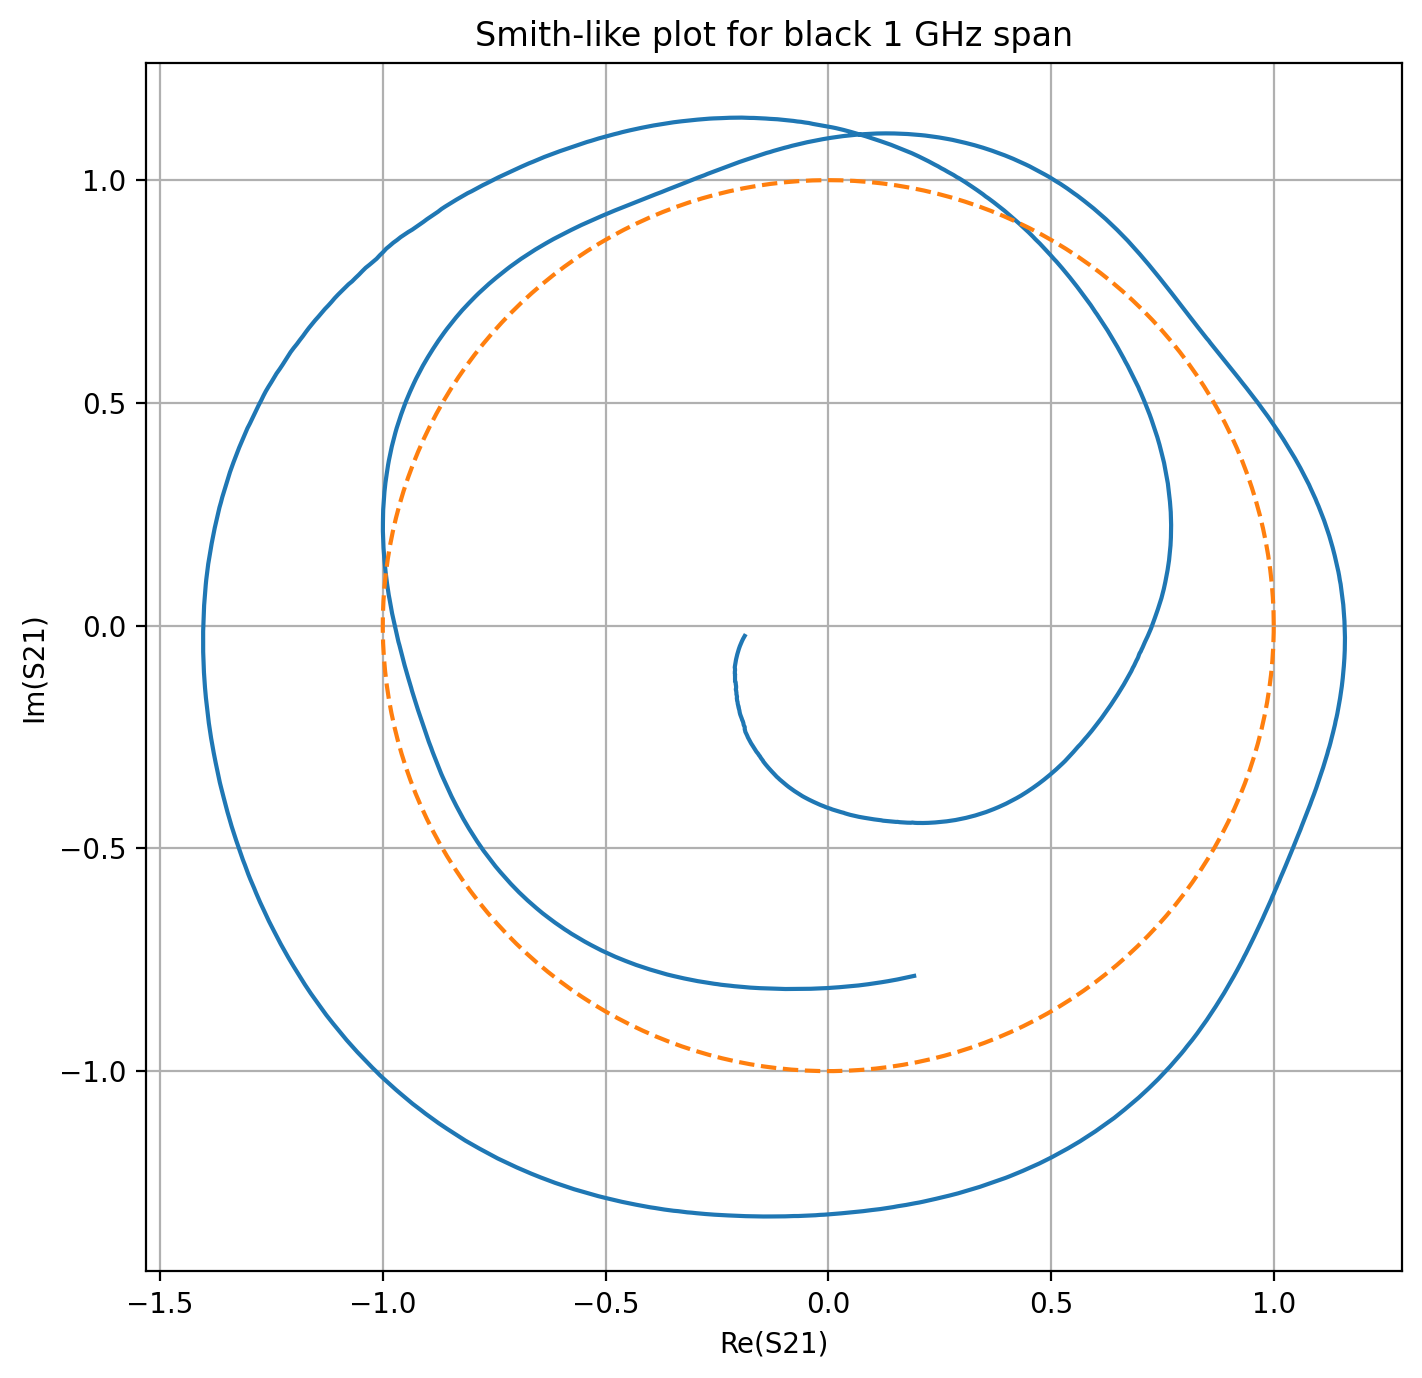

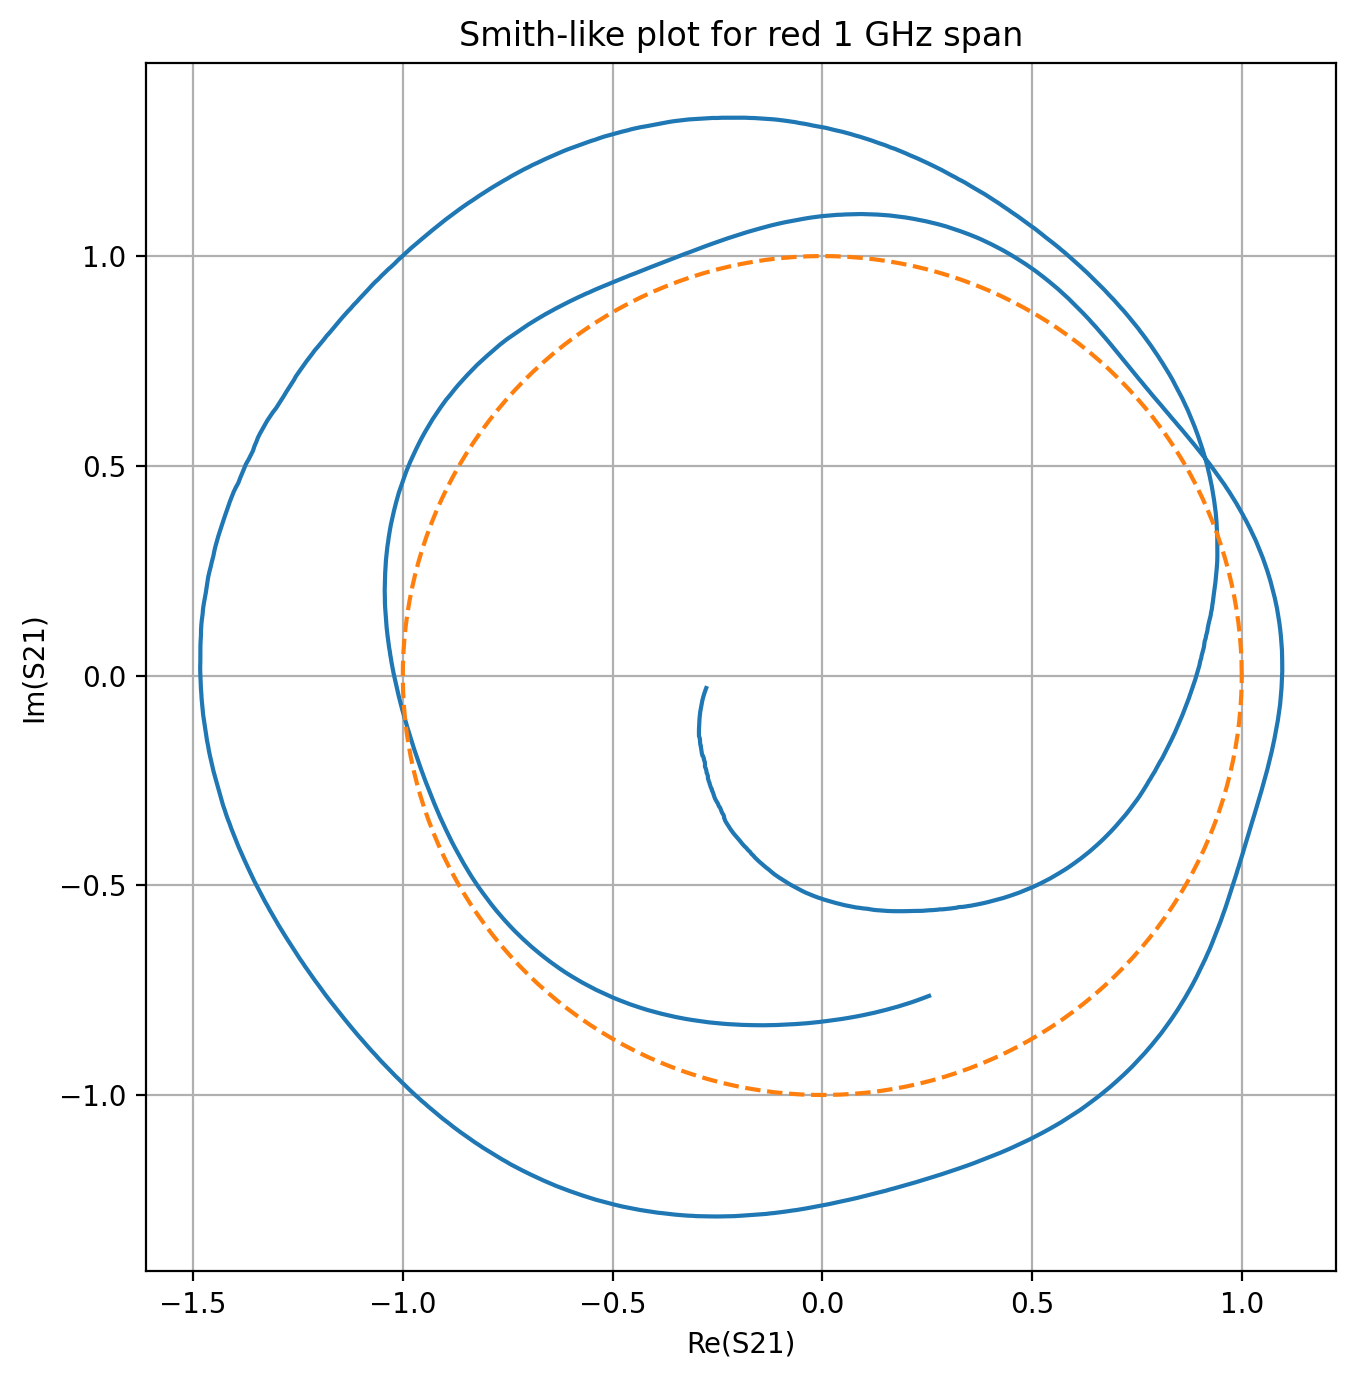

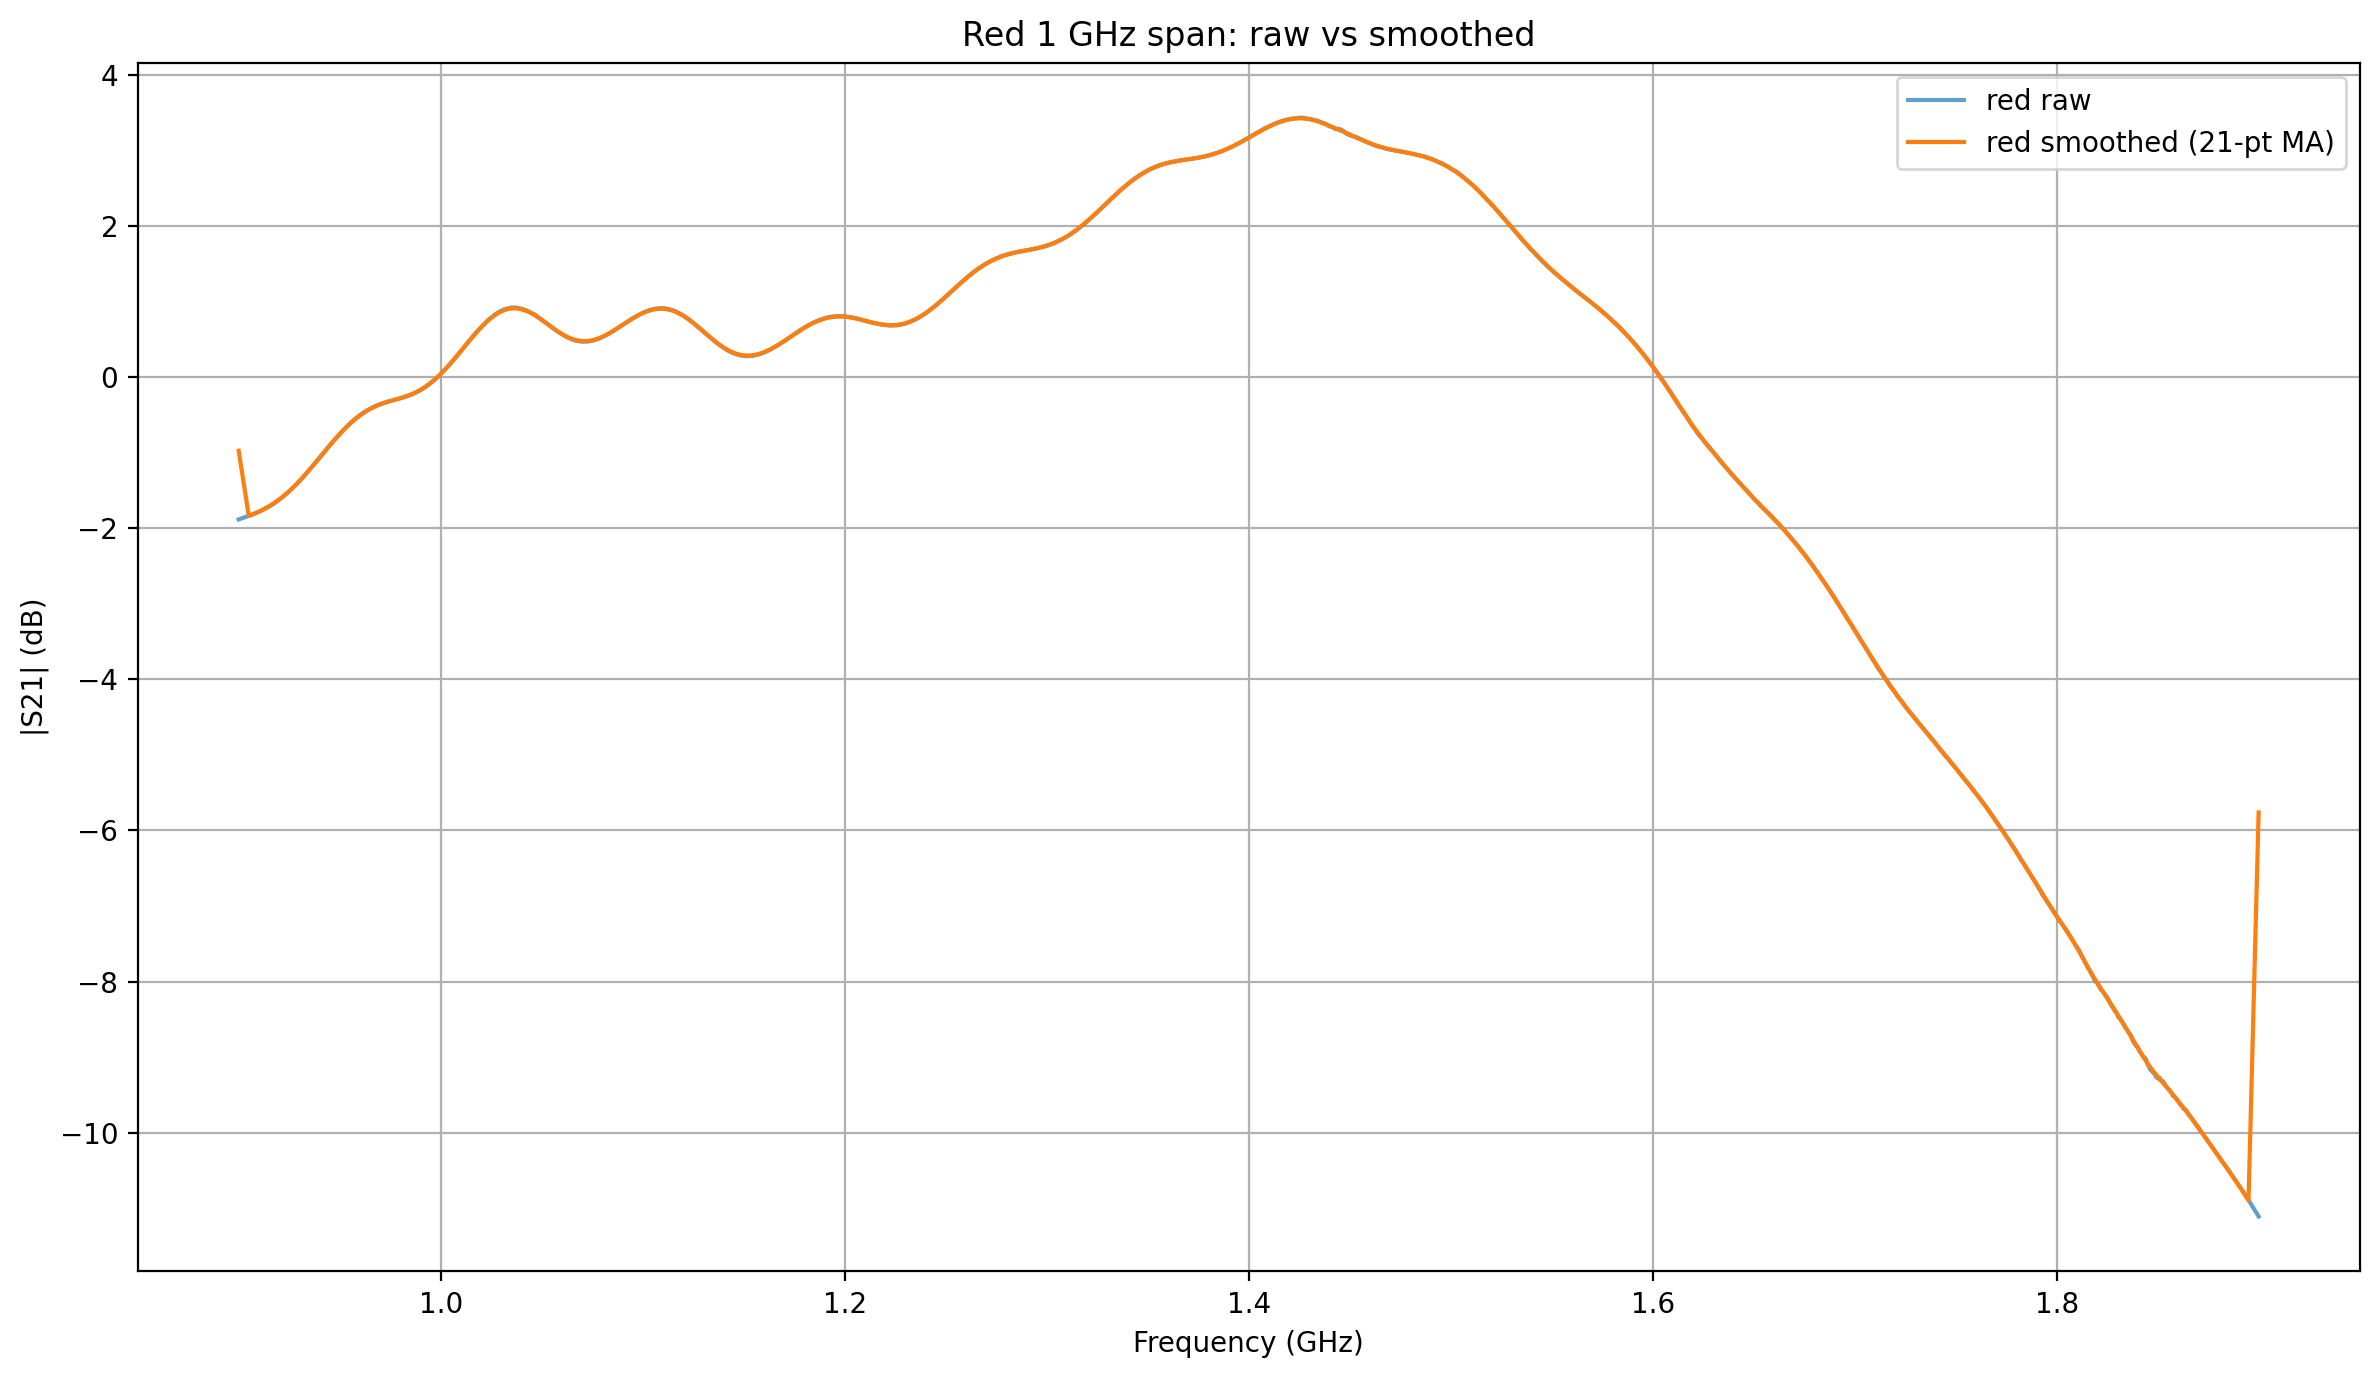

3dB passband result
[black 1GHz span]
 peak gain: 3.08 dB
 peak freq: 1.3587 GHz
3dB low: 1.0121 GHz
3dB high: 1.5288 GHz
passband: 516.8 MHz

[red 1GHz span]
 peak gain: 3.44 dB
 peak freq: 1.4258 GHz
3dB low: 1.0131 GHz
3dB high: 1.5913 GHz
passband: 578.3 MHz



In [11]:
# Group Delay
# Group Delay
f_mid_b, tau_b = compute_group_delay(black_1g)
f_mid_r, tau_r = compute_group_delay(red_1g)

plt.figure()
plt.plot(f_mid_b/1e9, tau_b*1e9, label="black GD")
plt.plot(f_mid_r/1e9, tau_r*1e9, label="red GD")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Group delay (ns)")
plt.title("Group delay around 1 GHz span")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Smith-like plot
def smith_like(df, label="trace"):
    plt.figure()
    plt.plot(df["re_S21"], df["im_S21"])

    theta = np.linspace(0, 2*np.pi, 400)
    plt.plot(np.cos(theta), np.sin(theta), linestyle="--")
    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.title(f"Smith-like plot for {label}")
    plt.gca().set_aspect("equal", "box")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

smith_like(black_1g, "black 1 GHz span")
smith_like(red_1g,   "red 1 GHz span")

# smooth the gain curve
red_1g_smooth = moving_average(red_1g["mag_dB"].values, N=21)

plt.figure()
plt.plot(red_1g["freq_Hz"]/1e9, red_1g["mag_dB"],     label="red raw", alpha=0.7)
plt.plot(red_1g["freq_Hz"]/1e9, red_1g_smooth,        label="red smoothed (21-pt MA)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21| (dB)")
plt.title("Red 1 GHz span: raw vs smoothed")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

res_black_1g = band_3dB(black_1g, "black 1GHz span")
res_red_1g   = band_3dB(red_1g,   "red 1GHz span")

print("3dB passband result")
for r in (res_black_1g, res_red_1g):
    print(f"[{r['label']}]")
    print(f" peak gain: {r['peak_gain_dB']:.2f} dB")
    print(f" peak freq: {r['peak_freq_Hz']/1e9:.4f} GHz")
    print(f"3dB low: {r['f_low_Hz']/1e9:.4f} GHz")
    print(f"3dB high: {r['f_high_Hz']/1e9:.4f} GHz")
    print(f"passband: {(r['f_high_Hz']-r['f_low_Hz'])/1e6:.1f} MHz\n")
